# 17 — TNG100 satellite richness: MW-mass hosts vs clusters ($M_{*,\rm sat}>10^8\,M_\odot$)

How many satellites with $M_* > 10^8\,M_\odot$ does a host halo have **on average**, comparing

* **MW-mass hosts** — $12.0 < \log_{10}(M_{200c}/M_\odot) < 12.5$, and
* **cluster hosts** — $\log_{10}(M_{200c}/M_\odot) \ge 14$ (i.e. $M_{200c}\ge10^{14}\,M_\odot$),

in **TNG100** at **z = 0**. Fiducial richness counts satellites **within $1\,R_{200c}$** (3D);
we also report the all-radius count for context.

### Data & the denominator caveat
We use the committed per-satellite catalogs (`..._allsat_logM8.00.csv`), whose columns
`mstar_phys` and `host_m200_phys` are **$\log_{10}(M/M_\odot)$, physical** (see
`../docs/conventions.md`). Each row is one satellite, so a halo with **zero** qualifying
satellites has no rows. Notebook 01 assigns host ids $0\ldots N_{\rm host}-1$ over *all* selected
hosts, so `max(host_id)+1` recovers the total number of selected halos in a bin — including the
empty ones. The true "per-halo" average therefore divides by that total, not by the number of
halos that happen to appear in the catalog:

| quantity | denominator |
|---|---|
| mean per **hosting** halo | # halos with $\ge1$ satellite (rows present) |
| mean per **selected** halo *(fiducial)* | total halos in the mass bin (incl. empties) |

For clusters every halo hosts many satellites, so the two denominators coincide there; for
MW-mass halos a sizeable fraction have no $M_*>10^8\,M_\odot$ satellite within $R_{200c}$, so the
distinction matters.

| bin | file | host cut |
|---|---|---|
| MW-mass | `tng100_satellites_hostlogM12.0-12.5_allsat_logM8.00.csv` | $12.0<\log M_{200c}<12.5$ |
| cluster | `tng100_satellites_hostlogM13.0plus_allsat_logM8.00.csv` (then $\log M_{200c}\ge14$) | $\ge10^{14}\,M_\odot$ |

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# --- configuration -----------------------------------------------------------
DATA_DIR = "../data/tng100/z0"
MW_FILE  = "tng100_satellites_hostlogM12.0-12.5_allsat_logM8.00.csv"
CL_FILE  = "tng100_satellites_hostlogM13.0plus_allsat_logM8.00.csv"

CLUSTER_LOGM_MIN = 14.0     # log10(M200c/Msun) >= 14  ->  M200c >= 1e14
RMAX_R200        = 1.0      # fiducial aperture: satellites within 1 R_200c (3D)

MW_C, CL_C = "#1f77b4", "#d62728" 

## Load the two catalogs

The cluster bin is the $\log M_{200c}\ge13$ catalog filtered to $\log M_{200c}\ge14$. Both are
already the $M_*>10^8\,M_\odot$ satellite cut; `d_r200_3d` is the 3D host-centric distance in units
of $R_{200c}$.

In [2]:
mw = pd.read_csv(f"{DATA_DIR}/{MW_FILE}")
cl = pd.read_csv(f"{DATA_DIR}/{CL_FILE}")
cl = cl[cl["host_m200_phys"] >= CLUSTER_LOGM_MIN].reset_index(drop=True)

# total selected halos per bin (host ids run 0..N-1 over all selected hosts, incl. empties)
n_sel_mw = int(mw["host_id"].max()) + 1
n_sel_cl = int(cl["host_id"].nunique())   # clusters are never empty -> present count = total

print(f"MW-mass : {len(mw):5d} satellite rows (all radii),  {n_sel_mw:4d} selected halos "
      f"[log M200c in ({mw['host_m200_phys'].min():.2f}, {mw['host_m200_phys'].max():.2f})]")
print(f"cluster : {len(cl):5d} satellite rows (all radii),  {n_sel_cl:4d} selected halos "
      f"[log M200c in ({cl['host_m200_phys'].min():.2f}, {cl['host_m200_phys'].max():.2f})]")

MW-mass :  3198 satellite rows (all radii),  1301 selected halos [log M200c in (12.00, 12.50)]
cluster :  3353 satellite rows (all radii),    10 selected halos [log M200c in (14.02, 14.58)]


## Richness statistics

For a given aperture (all radii, or within $1\,R_{200c}$) we count satellites per host, then report
the mean per **hosting** halo and per **selected** halo (the latter includes the empty halos as
zeros — the true average richness).

In [3]:
def richness(df, n_selected, rmax=None):
    '''Per-halo satellite counts and summary for a bin. rmax in units of R200c (None = all radii).'''
    d = df if rmax is None else df[df["d_r200_3d"] <= rmax]
    per_host = d.groupby("host_id").size()                 # counts for hosting halos only
    n_hosting = per_host.size
    counts = np.concatenate([per_host.to_numpy(),
                             np.zeros(n_selected - n_hosting, dtype=int)])   # pad empties
    return dict(n_sat=int(d.shape[0]), n_hosting=n_hosting, n_selected=n_selected,
                mean_hosting=d.shape[0] / n_hosting,
                mean_selected=d.shape[0] / n_selected,
                median_selected=float(np.median(counts)), max=int(counts.max()),
                counts=counts)

bins = {"MW-mass (12.0-12.5)": (mw, n_sel_mw, MW_C),
        "cluster (>=1e14)":     (cl, n_sel_cl, CL_C)}

stats = {}
for name, (df, nsel, _) in bins.items():
    stats[name] = {"within R200": richness(df, nsel, RMAX_R200),
                   "all radii":   richness(df, nsel, None)}

# summary table
rows = []
for name in bins:
    for ap in ("within R200", "all radii"):
        s = stats[name][ap]
        rows.append({"bin": name, "aperture": ap, "N_sat": s["n_sat"],
                     "hosting halos": s["n_hosting"], "selected halos": s["n_selected"],
                     "mean / hosting": round(s["mean_hosting"], 2),
                     "mean / selected": round(s["mean_selected"], 2),
                     "median / selected": s["median_selected"], "richest halo": s["max"]})
summary = pd.DataFrame(rows).set_index(["bin", "aperture"])
summary

N_sat  hosting halos  selected halos  \
bin                 aperture                                            
MW-mass (12.0-12.5) within R200   2165            867            1301   
                    all radii     3198            959            1301   
cluster (>=1e14)    within R200   2051             10              10   
                    all radii     3353             10              10   

                                 mean / hosting  mean / selected  \
bin                 aperture                                       
MW-mass (12.0-12.5) within R200            2.50             1.66   
                    all radii              3.33             2.46   
cluster (>=1e14)    within R200          205.10           205.10   
                    all radii            335.30           335.30   

                                 median / selected  richest halo  
bin                 aperture                                      
MW-mass (12.0-12.5) within R200                1.0            22  
                    all radii                  2.0            23  
cluster (>=1e14)    within R200              174.5           431  
                    all radii                301.5           729

## Headline comparison

Fiducial answer = **mean satellites ($M_*>10^8\,M_\odot$) within $1\,R_{200c}$ per selected halo**.

In [4]:
mw_mean = stats["MW-mass (12.0-12.5)"]["within R200"]["mean_selected"]
cl_mean = stats["cluster (>=1e14)"]["within R200"]["mean_selected"]
print(f"MW-mass host  (12.0-12.5) : {mw_mean:6.2f} satellites per halo  (within R200, M* > 1e8)")
print(f"cluster host  (>=1e14)    : {cl_mean:6.2f} satellites per halo  (within R200, M* > 1e8)")
print(f"ratio cluster / MW-mass   : {cl_mean / mw_mean:6.1f}x")

MW-mass host  (12.0-12.5) :   1.66 satellites per halo  (within R200, M* > 1e8)
cluster host  (>=1e14)    : 205.10 satellites per halo  (within R200, M* > 1e8)
ratio cluster / MW-mass   :  123.2x


## Figure 1 — mean satellite richness per halo

Bars = mean per **selected** halo (fiducial, includes empty halos); faded bars = mean per
**hosting** halo. Within $1\,R_{200c}$, $M_*>10^8\,M_\odot$. Note the log $y$-axis.

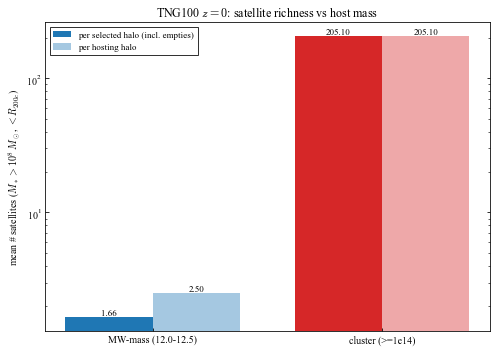

In [5]:
names = list(bins)
x = np.arange(len(names))
w = 0.38
sel = [stats[n]["within R200"]["mean_selected"] for n in names]
hos = [stats[n]["within R200"]["mean_hosting"]  for n in names]
cols = [bins[n][2] for n in names]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - w/2, sel, w, color=cols, label="per selected halo (incl. empties)")
ax.bar(x + w/2, hos, w, color=cols, alpha=0.4, label="per hosting halo")
for xi, (a, b) in enumerate(zip(sel, hos)):
    ax.text(xi - w/2, a, f"{a:.2f}", ha="center", va="bottom", fontsize=9)
    ax.text(xi + w/2, b, f"{b:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel(r"mean # satellites ($M_* > 10^8\,M_\odot$, $<R_{200c}$)")
ax.set_title(r"TNG100 $z=0$: satellite richness vs host mass")
ax.legend(fancybox=False, edgecolor="k", fontsize=9)
ax.tick_params(which="both", direction="in", right=True)
plt.tight_layout(); plt.show()

## Figure 2 — distribution of satellites per halo

Per-halo satellite counts (within $1\,R_{200c}$), including the zero-satellite halos. Vertical
dashed lines mark the per-selected-halo means. Left/right share the count axis but the scales
differ hugely, so each bin gets its own panel.

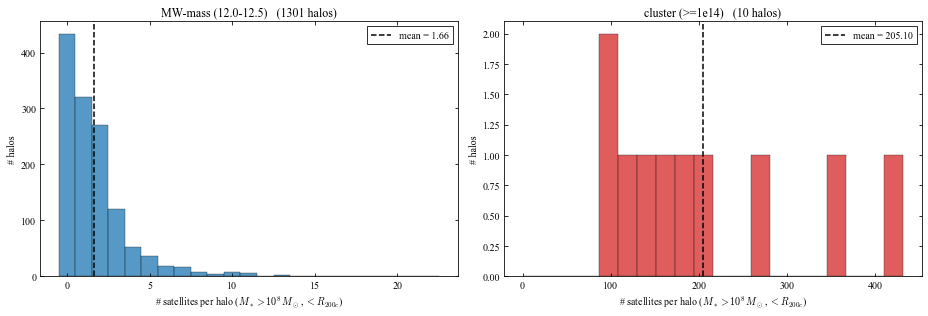

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name in zip(axes, names):
    s = stats[name]["within R200"]
    c = bins[name][2]
    counts = s["counts"]
    bmax = counts.max()
    # unit-wide bins when counts are small (MW), ~20 equal bins when large (cluster)
    edges = np.arange(0, bmax + 2) - 0.5 if bmax <= 30 else np.linspace(0, bmax, 21)
    ax.hist(counts, bins=edges, color=c, alpha=0.75, edgecolor="k", lw=0.4)
    ax.axvline(s["mean_selected"], color="k", ls="--", lw=1.5,
               label=f"mean = {s['mean_selected']:.2f}")
    ax.set_xlabel(r"# satellites per halo ($M_*>10^8\,M_\odot$, $<R_{200c}$)")
    ax.set_ylabel("# halos")
    ax.set_title(f"{name}   ({s['n_selected']} halos)")
    ax.legend(fancybox=False, edgecolor="k")
    ax.tick_params(which="both", direction="in", top=True, right=True)
plt.tight_layout(); plt.show()

## Takeaways

* **MW-mass hosts ($12.0<\log M_{200c}<12.5$)** host on average **~1.7** satellites with
  $M_*>10^8\,M_\odot$ within $R_{200c}$ (≈2.5 among the halos that host at least one; a large
  fraction have none).
* **Cluster hosts ($\ge10^{14}\,M_\odot$)** host on average **~200** such satellites — roughly
  **two orders of magnitude** richer, with the richest halo exceeding 400.
* The all-radius counts (out to several $R_{200c}$) are higher for both bins but include
  interlopers; the within-$R_{200c}$ numbers are the physically meaningful richness.
* Change `CLUSTER_LOGM_MIN` or `RMAX_R200` to redefine the cluster threshold or the aperture, or
  point `DATA_DIR` at `../data/tng100/z0p05` for the z=0.05 snapshot.